In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import umap

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
classes = train_dataset.classes

100%|██████████| 170M/170M [00:10<00:00, 15.8MB/s]


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc = nn.Linear(64 * 4 * 4, 2)

        self.decoder = nn.Sequential(
            nn.Linear(2, 64 * 4 * 4),
            nn.Unflatten(1, (64, 4, 4)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        bottleneck = self.fc(encoded.view(x.size(0), -1))
        decoded = self.decoder(bottleneck)
        return bottleneck, decoded

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()
print("Training autoencoder...")
for epoch in range(20):
    for images, _ in train_loader:
        images = images.to(device)
        bottleneck, outputs = autoencoder(images)
        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

Training autoencoder...
Epoch 1: Loss = 0.0336
Epoch 2: Loss = 0.0379
Epoch 3: Loss = 0.0393
Epoch 4: Loss = 0.0386
Epoch 5: Loss = 0.0380
Epoch 6: Loss = 0.0369
Epoch 7: Loss = 0.0375
Epoch 8: Loss = 0.0380
Epoch 9: Loss = 0.0361
Epoch 10: Loss = 0.0351
Epoch 11: Loss = 0.0350
Epoch 12: Loss = 0.0394
Epoch 13: Loss = 0.0337
Epoch 14: Loss = 0.0329
Epoch 15: Loss = 0.0404
Epoch 16: Loss = 0.0376
Epoch 17: Loss = 0.0372
Epoch 18: Loss = 0.0371
Epoch 19: Loss = 0.0348
Epoch 20: Loss = 0.0373


In [ ]:
def extract_autoencoder_features(model, loader, device):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z, _ = model(x)
            features.append(z.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

ae_features, ae_labels = extract_autoencoder_features(autoencoder, train_loader, device)

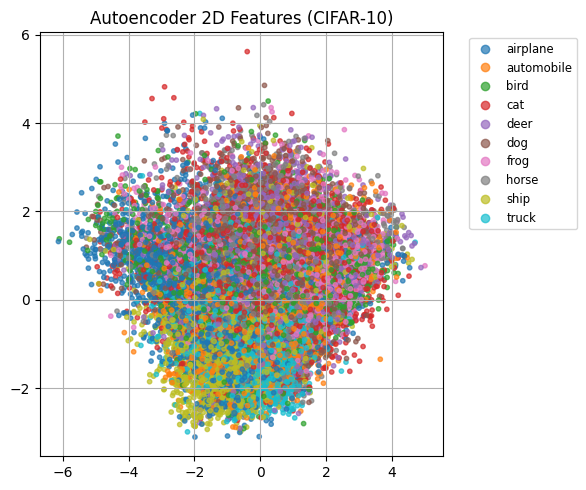

In [ ]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(ae_features[:, 0], ae_features[:, 1], c=ae_labels, cmap='tab10', s=10, alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=classes, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.title("Autoencoder 2D Features (CIFAR-10)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from torchvision.models import resnet101
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        model = resnet101(pretrained=True)
        self.backbone = nn.Sequential(*list(model.children())[:-1])  # remove FC

    def forward(self, x):
        x = self.backbone(x)
        return x.view(x.size(0), -1)

resnet_model = ResNetFeatureExtractor().to(device).eval()

def extract_resnet_features(model, loader, device):
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feats = model(x)
            features.append(feats.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

resnet_feats, resnet_labels = extract_resnet_features(resnet_model, train_loader, device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 180MB/s]


In [ ]:
pca_feats = PCA(n_components=2).fit_transform(resnet_feats)
tsne_feats = TSNE(n_components=2, perplexity=30, init='pca').fit_transform(resnet_feats[:2000])
tsne_labels = resnet_labels[:2000]


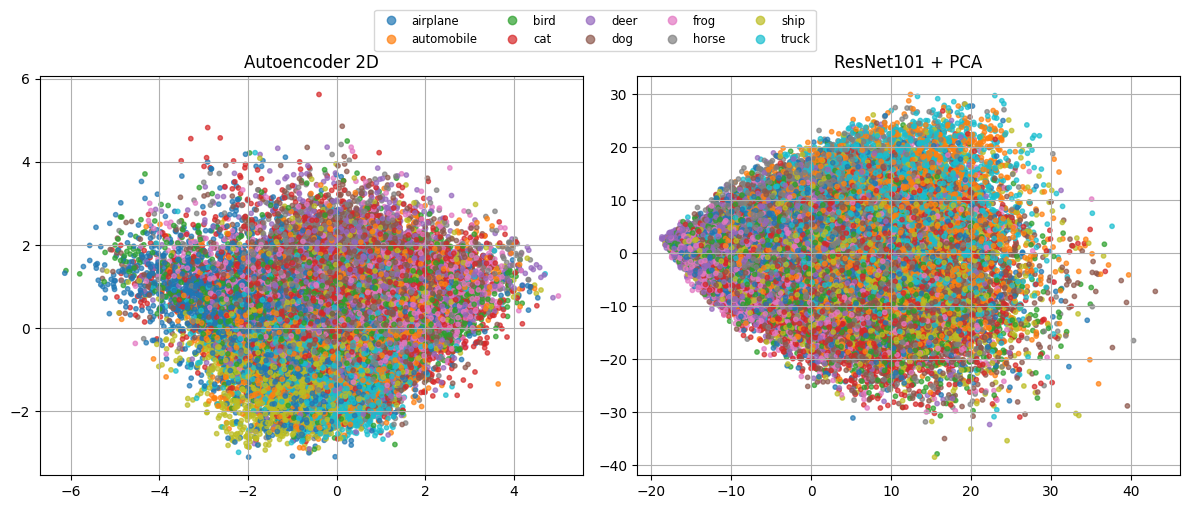

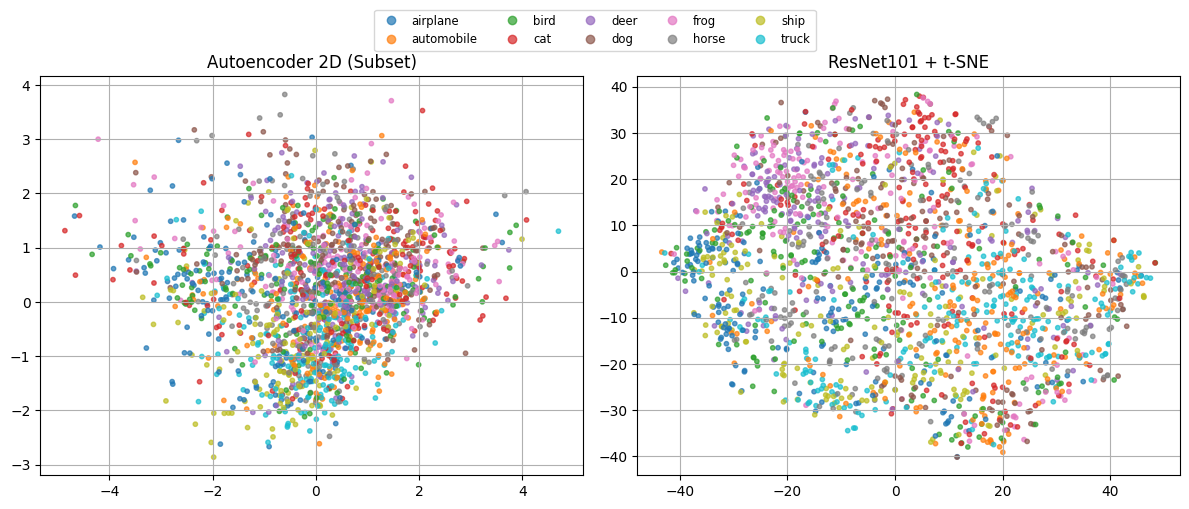

In [ ]:
def plot_comparison(feat1, labels1, feat2, labels2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    scatter1 = axes[0].scatter(feat1[:, 0], feat1[:, 1], c=labels1, cmap='tab10', s=10, alpha=0.7)
    scatter2 = axes[1].scatter(feat2[:, 0], feat2[:, 1], c=labels2, cmap='tab10', s=10, alpha=0.7)

    axes[0].set_title(title1)
    axes[1].set_title(title2)
    for ax in axes:
        ax.grid(True)
    fig.legend(handles=scatter1.legend_elements()[0], labels=classes,
               bbox_to_anchor=(0.5, 1.02), loc='upper center',
               ncol=5, fontsize='small')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_comparison(ae_features, ae_labels, pca_feats, resnet_labels, "Autoencoder 2D", "ResNet101 + PCA")
plot_comparison(ae_features[:2000], ae_labels[:2000], tsne_feats, tsne_labels, "Autoencoder 2D (Subset)", "ResNet101 + t-SNE")